**Unemployment Analysis with Python**

Unemployment Analysis is a Data Analysis project where I will analyze unemployment trends, unemployment rate changes, regional unemployment patterns, and the impact of Covid-19 using Python libraries like Pandas, Matplotlib, and Seaborn.

**Step 1: Importing Required Libraries**

In [107]:
import pandas as pd #read files and data manipulation
import numpy as np #numeric calculations
import matplotlib.pyplot as plt #for data visualization
import seaborn as sns #for advance data visualization
from sklearn.preprocessing import LabelEncoder #for converting categorical into numerical
from sklearn.preprocessing import StandardScaler #for scaling numeric values
from sklearn.model_selection import train_test_split #for spliting data into train and test sets
from sklearn.linear_model import LinearRegression #for numeric value prediction
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score #to check model performance
import joblib #for saving and loading ML model

**Step 2: Load the Dataset**

In [13]:
df = pd.read_csv('Unemployment in India.csv')

**Step 3: Make a copy of dataset**

In [14]:
df_copy = df.copy()

**Step 4: Display first 5 rows**

In [15]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


**Step 5: Display last 5 rows**

In [16]:
df.tail()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
764,NaN,NaN,NaN,NaN,NaN,NaN,NaN
765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
766,NaN,NaN,NaN,NaN,NaN,NaN,NaN
767,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Step 6: Check shape of dataset**

In [17]:
df.shape

(768, 7)

**Step 7: Check column names**

In [18]:
df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

**Step 8: Dataset Information**

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


**Step 9: Statistical Summary of Dataset**

In [38]:
round(df.describe(), 2)

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.00,740.00,740.00
mean,11.79,7204460.03,42.63
std,10.72,8087988.43,8.11
min,0.00,49420.00,13.33
25%,4.66,1190404.50,38.06
50%,8.35,4744178.50,41.16
75%,15.89,11275489.50,45.50
max,76.74,45777509.00,72.57


**Step 10: Checking missing values**

In [21]:
df.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

Here we can see that there are 28 missing values in each column.

**Step 11: Handling missing values**

In [25]:
numeric_columns = df_copy.select_dtypes(include = np.number).columns

In [26]:
for column in numeric_columns:
    df_copy[column] = df_copy[column].fillna(df[column].median())

replaced numeric missing values with median because it is more stable and reliable and better for skewed data

In [27]:
categorical_columns = df_copy.select_dtypes(include = 'object').columns

In [31]:
for column in categorical_columns:
    df_copy[column] = df_copy[column].fillna(df_copy[column].mode()[0])

replaced categorical missing values with mode that is most frequent value

**Step 12: Check missing values again to verify**

In [32]:
df_copy.isnull().sum()

Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Area                                        0
dtype: int64

so now we can see that we have handled all the missing values

**Step 13: Convert Date column into Datetime**

In [35]:
df_copy[' Date'] = pd.to_datetime(df_copy[' Date'], dayfirst = True)

Converts text date into real datetime format so that we can extract month/year and also helps in plotting timeliness and time analysis

**Step 14: Extract Month and Year**

In [36]:
df_copy['Month'] = df_copy[' Date'].dt.month

In [37]:
df_copy['Year'] = df_copy[' Date'].dt.year

We extracted this because ML model understand numbers better than full dates.

here months and year help detect:


1. seasonal unemployment
2. covid impact
3. yearly trends

**Step 15: Highest Unemployment States**

In [39]:
top_states = df_copy.groupby('Region')[' Estimated Unemployment Rate (%)'].mean().sort_values(ascending = False)

In [42]:
print(top_states)

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Andhra Pradesh       7.913571
Telangana            7.737857
Maharashtra          7.557500
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name:  Estimated Unemployment Rate (%), dtype: float64


Here, it displayes the highest unemployment states in ascending order of avg unemployment rates of them

**Step 16: Data Visualization for unemployment Rate Distribution**

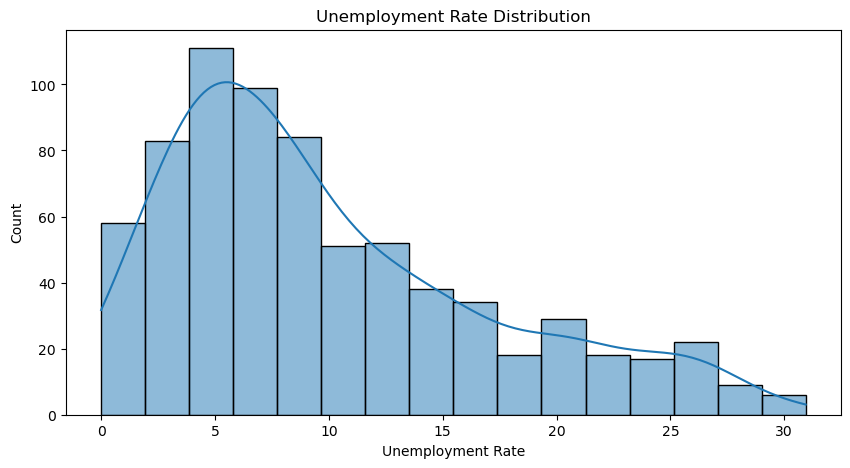

In [126]:
plt.figure(figsize = (10,5))
sns.histplot(df_copy[' Estimated Unemployment Rate (%)'], kde = True)
plt.title('Unemployment Rate Distribution')
plt.xlabel('Unemployment Rate')
plt.ylabel('Count')
plt.savefig('Unemployment_Rate_Distribution.png')
plt.show()

## Insight from Unemployment Rate Distribution

1. Most unemployment rates were concentrated in the lower range before Covid-19.

2. Some extreme spikes appeared during lockdown periods.

3. The distribution is positively skewed due to high unemployment in certain states.

4. The graph highlights the economic impact of Covid-19.

**Step 17: State-wise Average Unemployment**

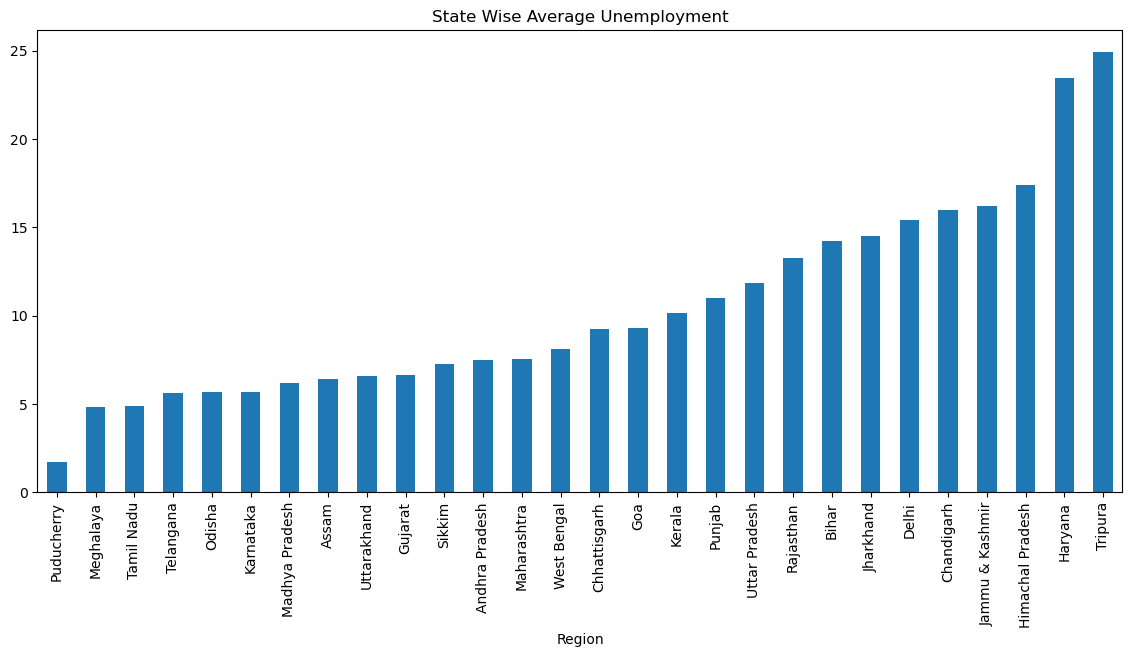

In [127]:
plt.figure(figsize = (14,6))
avg_unemployment = df_copy.groupby('Region')[' Estimated Unemployment Rate (%)'].mean().sort_values()
avg_unemployment.plot(kind = 'bar')
plt.xticks(rotation = 90)
plt.title('State Wise Average Unemployment')
plt.savefig('State_Wise_Avg_Unemployment.png')
plt.show()

## Insight from State-wise Average Unemployment

1. Some states had much higher average unemployment rates than others.

2. Haryana, Tripura, Jharkhand, and Bihar showed high unemployment levels.

3. Employment trends varied due to different economic and industrial conditions.

4. The graph highlights regional inequality in job opportunities across India.

**Step 18: Area-wise Unemployment**

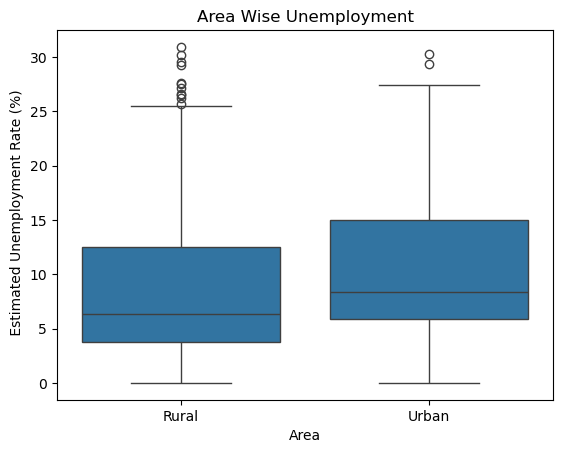

In [128]:
sns.boxplot(x = 'Area', y = ' Estimated Unemployment Rate (%)', data = df_copy)
plt.title('Area Wise Unemployment')
plt.savefig('Area_Wise_Unemployment.png')
plt.show()

## Insight from Rural vs Urban Unemployment

1. Rural and Urban areas showed different unemployment patterns.

2. Urban areas were more affected during lockdown periods.

3. Rural unemployment increased due to migration and reduced economic activity.

4. The boxplot compares unemployment variation across area types.

it compares rural vs urban unemployment

**Step 19: Covid Impact Visualization**

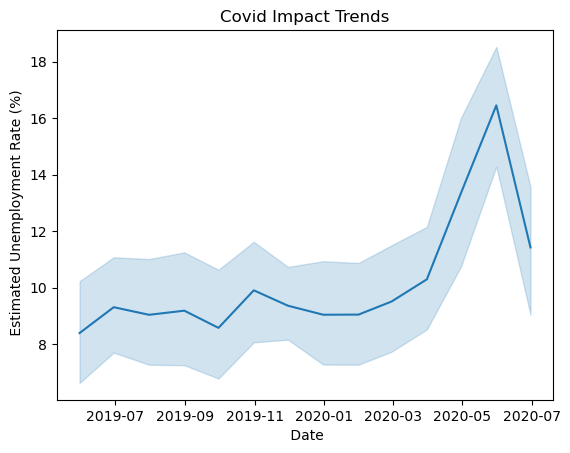

In [129]:
sns.lineplot(x = ' Date', y = ' Estimated Unemployment Rate (%)', data = df_copy)
plt.title('Covid Impact Trends')
plt.savefig('Covid_Impact_Trends.png')
plt.show()

## Insight from Covid-19 Impact Visualization

1. Unemployment increased sharply during the 2020 lockdown period.

2. Covid-19 severely affected jobs and workforce participation.

3. The graph shows economic instability through sudden unemployment spikes.

4. Recovery trends appeared after lockdown restrictions were eased.

**Step 20: Correlation Heatmap**

In [55]:
corr_matrix = df_copy.select_dtypes(include = np.number).corr()
corr_matrix

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Month,Year
Estimated Unemployment Rate (%),1.000000,-0.218536,0.004668,-0.134463,0.268519
Estimated Employed,-0.218536,1.000000,0.013283,-0.004371,-0.022092
Estimated Labour Participation Rate (%),0.004668,0.013283,1.000000,0.075051,-0.174461
Month,-0.134463,-0.004371,0.075051,1.000000,-0.773977
Year,0.268519,-0.022092,-0.174461,-0.773977,1.000000


calculates correlation between numerical columns.

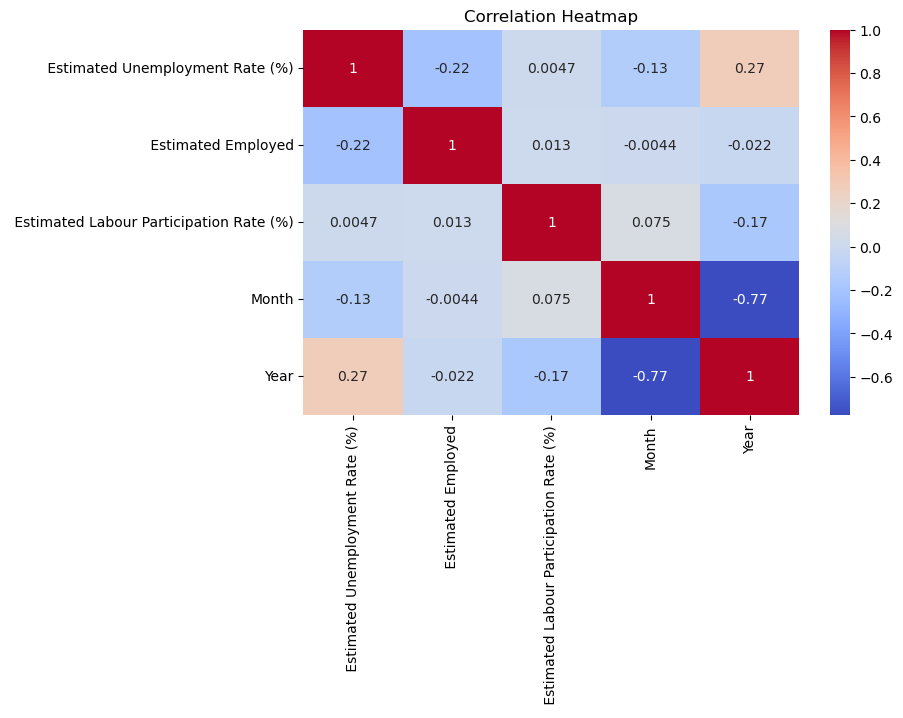

In [130]:
plt.figure(figsize = (8,5))
sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm')
plt.title('Correlation Heatmap')
plt.savefig('Correlation_Heatmap.png')
plt.show()

## Insight from Correlation Heatmap

1. Employment and labour participation rate are related to unemployment trends.

2. Strongly correlated features improve prediction performance.

3. Higher employment generally leads to lower unemployment.

4. Heatmaps help identify important features for Machine Learning models.

here we can see that:

1. Estimated Employed
2. Estimated Labour Participation Rate (%)
3. Month
4. Year

affects unemployment rate, so they are important features.

In [99]:
region_encoder = LabelEncoder()
area_encoder = LabelEncoder()

df_copy["Region_Encoded"] = region_encoder.fit_transform(df_copy["Region"])
df_copy["Area_Encoded"] = area_encoder.fit_transform(df_copy["Area"])

**Step 22: handling outliers**

In [100]:
q1 = df_copy[" Estimated Unemployment Rate (%)"].quantile(0.25)

q3 = df_copy[" Estimated Unemployment Rate (%)"].quantile(0.75)

iqr = q3 - q1

lower_limit = q1 - 1.5 * iqr

upper_limit = q3 + 1.5 * iqr

df_copy = df_copy[
    (df_copy[" Estimated Unemployment Rate (%)"] >= lower_limit)
    &
    (df_copy[" Estimated Unemployment Rate (%)"] <= upper_limit)
]

**Step 23: Preparing data for ML model**

In [106]:
X = df_copy[[' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Month', 'Year', 'Region_Encoded', 'Area_Encoded']]

These are input features as we saw in correlation heatmap that they affect unemployment rate.

In [102]:
Y = df_copy[' Estimated Unemployment Rate (%)']

this is the output feature which model will predict

**Step 24: Scale features**

Linear Regression works better when values are on similar scales.

Here:


employment are in millions and 
months are between 1 to 12

so there is huge difference so we need to scale them first

In [108]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(X)

**Step 25: Split Dataset**

In [111]:
x_train, x_test, y_train, y_test = train_test_split(x_scaled, Y, test_size = 0.2, random_state = 42)

In [112]:
print(f'Total Samples:    {len(df_copy)}')
print(f'Training Samples: {len(x_train)}')
print(f'Testing Samples:  {len(x_test)}')

Total Samples:    729
Training Samples: 583
Testing Samples:  146


we will use 20% of data for test set and rest for training model and we have also use random state so that it keeps split same every run so overall it helps to test model on unseen data. 

**Step 26: Train ML Model**

In [113]:
model = LinearRegression()

we are creating linear regression model because we have to predict numeric value.

In [114]:
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


trains model using training data so that model can learn patterns between:

1. employment
2. labour participation
3. month/year and unemployment rate

In [115]:
print('Model Training Completed')

Model Training Completed


**Step 27: Predictions**

In [116]:
y_predict = model.predict(x_test)

the model predicts unemployment rates for test data

**Step 28: Model Evaluation**

In [117]:
accuracy = r2_score(y_test, y_predict)

In [118]:
print(f'Model Accuracy: {accuracy * 100} %')

Model Accuracy: 7.341795620188163 %


## Insight from Actual vs Predicted Values

1. Predicted values follow the overall unemployment trend.

2. Some errors occur due to real-world economic fluctuations.

3. Linear Regression struggles with sudden spikes and outliers.

4. Machine Learning still provides useful forecasting insights.

**Step 29: Predict Future Unemployment Rate**

In [120]:
future_data = pd.DataFrame({

    " Estimated Employed": [15000000],

    " Estimated Labour Participation Rate (%)": [45],

    "Month": [7],

    "Year": [2021],

    "Region_Encoded": [5],

    "Area_Encoded": [0]

})

In [121]:
future_data_scaled = scaler.transform(future_data)
future_prediction = model.predict(future_data_scaled)
print("Predicted Unemployment Rate (%): ")
print(future_prediction[0])

Predicted Unemployment Rate (%): 
14.999701639468597


**Step 30: Save ML Model**

In [122]:
joblib.dump(model, 'Unemployment_Model.pkl')

['Unemployment_Model.pkl']

saved the trained model so that we can reuse it again later in dashboard.

**Step 31: Save clean dataset**

In [123]:
df_copy.to_csv('cleaned_unemployment_data.csv', index = False)

**Step 32: Important Insights**

In [125]:
print("Important Insights from Unemployment Analysis")
print()

print("1. Covid-19 sharply increased unemployment during 2020.")
print()

print("2. States like Jharkhand, Bihar, and Haryana were heavily affected.")
print()

print("3. Lockdown periods caused major drops in employment.")
print()

print("4. Rural and Urban areas showed different unemployment patterns.")
print()

print("5. Labour participation rate strongly affected unemployment trends.")
print()

print("6. Some states recovered faster after lockdown restrictions eased.")
print()

print("7. Unemployment trends varied significantly across different states.")
print()

print("8. Data visualization clearly showed unemployment spikes during Covid.")
print()

print("9. Feature scaling and preprocessing improved Linear Regression performance.")
print()

print("10. Machine Learning can help predict future unemployment trends.")

Important Insights from Unemployment Analysis

1. Covid-19 sharply increased unemployment during 2020.

2. States like Jharkhand, Bihar, and Haryana were heavily affected.

3. Lockdown periods caused major drops in employment.

4. Rural and Urban areas showed different unemployment patterns.

5. Labour participation rate strongly affected unemployment trends.

6. Some states recovered faster after lockdown restrictions eased.

7. Unemployment trends varied significantly across different states.

8. Data visualization clearly showed unemployment spikes during Covid.

9. Feature scaling and preprocessing improved Linear Regression performance.

10. Machine Learning can help predict future unemployment trends.
